# Dinaciclib: Tensor-based Analysis Across Cell Lines


In [1]:
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import phate

from cc_tensor import CCTensor
from cc_tensor_viz import CCTensorViz


/Users/kaiwycik/.pyenv/versions/3.13.3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DRUG = "Dinaciclib"
CELL_LINES = ["134", "231", "44PE", "453", "BCK4", "MCF10A", "MCF7", "T47D"]

features = [
    'nuclear_mean_Ki67', 'nuclear_area', 'nuclear_mean_p16', 
    'nuclear_mean_CDH1', 'nuclear_mean_cycA2', 'nuclear_mean_cycE1',
    'nuclear_mean_CDK2', 'nuclear_mean_RB', 'nuclear_mean_CycB1',
    'nuclear_mean_p21', 'nuclear_mean_cycD1', 'nuclear_mean_CDK6',
    'nuclear_mean_CDK4', 'nuclear_mean_cycA1', 'nuclear_mean_PCNA', 
    'nuclear_mean_p53', 'nuclear_mean_p27', 'nuclear_mean_cycB2', 
    'nuclear_mean_SKP2', 'nuclear_mean_CDT1', 'nuclear_mean_cycE2',
    'DNA_int'
]


## 1. Data import and preprocessing:

### 1.1 Data import and control referencing:

For each cell line we load the cells treated with Dinaciclib and the Control cells, restricted to the 22 proteins above and to phases G1, S and G2 (G0 and M are excluded, as in the per-cell-line notebooks).

Raw intensities are not comparable across cell lines: baseline expression and staining differ by up to an order of magnitude (e.g. median Control Ki67 is about 900 in MCF10A and about 19,000 in 453). We therefore z-score each line's cells against the mean $\boldsymbol{\mu}^{\text{ctrl}}_l$ and standard deviation $\boldsymbol{\sigma}^{\text{ctrl}}_l$ of that line's own Control cells,

$$
\tilde{\mathbf{x}} = \frac{\mathbf{x} - \boldsymbol{\mu}^{\text{ctrl}}_l}{\boldsymbol{\sigma}^{\text{ctrl}}_l},
$$

so that 0 is the Control mean of the cell line and the pooled data measure each line's response in units of its own Control variability. The lines are then pooled into one AnnData object with a `cell_line` column.

In [3]:
adatas = {}
for cl in CELL_LINES:
    a = ad.read_h5ad(f"data/breast_cancer_zikry_wayne/{cl}_merged.h5ad", backed="r")
    keep = ~a.obs["GMM_phase_labels"].isin(["G0", "M"])
    ctrl = a[(keep & (a.obs["drug_name"] == "Control")).values, features].to_memory()
    sub = a[(keep & (a.obs["drug_name"] == DRUG)).values, features].to_memory()
    sub.X = (sub.X - ctrl.X.mean(0)) / ctrl.X.std(0)
    adatas[cl] = sub
    a.file.close()

adata = ad.concat(adatas, label="cell_line", index_unique="-")
adata.obs["cell_line"] = pd.Categorical(adata.obs["cell_line"], categories=CELL_LINES)
adata.obs["GMM_phase_labels"] = adata.obs["GMM_phase_labels"].astype(str).astype("category")
adata

AnnData object with n_obs × n_vars = 103161 × 22
    obs: 'core', 'binucleated', 'CellID', 'GMM_phase_labels', 'DNA_int_obs', 'nuclear_mean_cycA2_obs', 'Endocycle', 'drug_name', 'cell_line'

### 1.2 Group sizes:

Cells per (cell line, phase) group. Pseudobulk means of very small groups are noisy.

In [4]:
adata.obs.groupby(["cell_line", "GMM_phase_labels"], observed=True).size().unstack()

GMM_phase_labels,G1,G2,S
cell_line,,,
134,7514,549,1932
231,370,84,262
44PE,3496,650,1266
453,17553,257,1502
BCK4,3222,1271,4774
MCF10A,1031,43,159
MCF7,1896,371,1461
T47D,35279,7568,10651


In [5]:
phases = list(adata.obs["GMM_phase_labels"].cat.categories)
proteins = [f.replace("nuclear_mean_", "") for f in adata.var_names]

### 1.3 Data overview via PHATE:

Before any tensor work, we embed a subsample of the control-referenced single-cell data into two dimensions using PHATE, which preserves local and global manifold structure. This provides a quick sanity check: do cell lines and cell-cycle phases separate in protein space, and which proteins dominate expression?

In [6]:
adata_sub = sc.pp.subsample(adata, n_obs=min(10000, adata.n_obs), copy=True, random_state=0)
data_phate = phate.PHATE().fit_transform(adata_sub.X)

phate_df = pd.DataFrame(data_phate, columns=["PHATE 1", "PHATE 2"], index=adata_sub.obs_names)
phate_df["cell_line"] = adata_sub.obs["cell_line"].astype(str).values
phate_df["phase"] = adata_sub.obs["GMM_phase_labels"].astype(str).values
phate_df["dominant_protein"] = adata_sub.to_df().idxmax(axis=1).str.removeprefix("nuclear_mean_").values

Calculating PHATE...
  Running PHATE on 10000 observations and 22 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.17 seconds.
    Calculating affinities...
    Calculated affinities in 0.79 seconds.
  Calculated graph and diffusion operator in 0.96 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.23 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.27 seconds.
  Calculated landmark operator in 1.50 seconds.
  Calculating optimal t...
    Automatically selected t = 18
  Calculated optimal t in 1.18 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.27 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.24 seconds.
Calculated PHATE in 5.43 seconds.


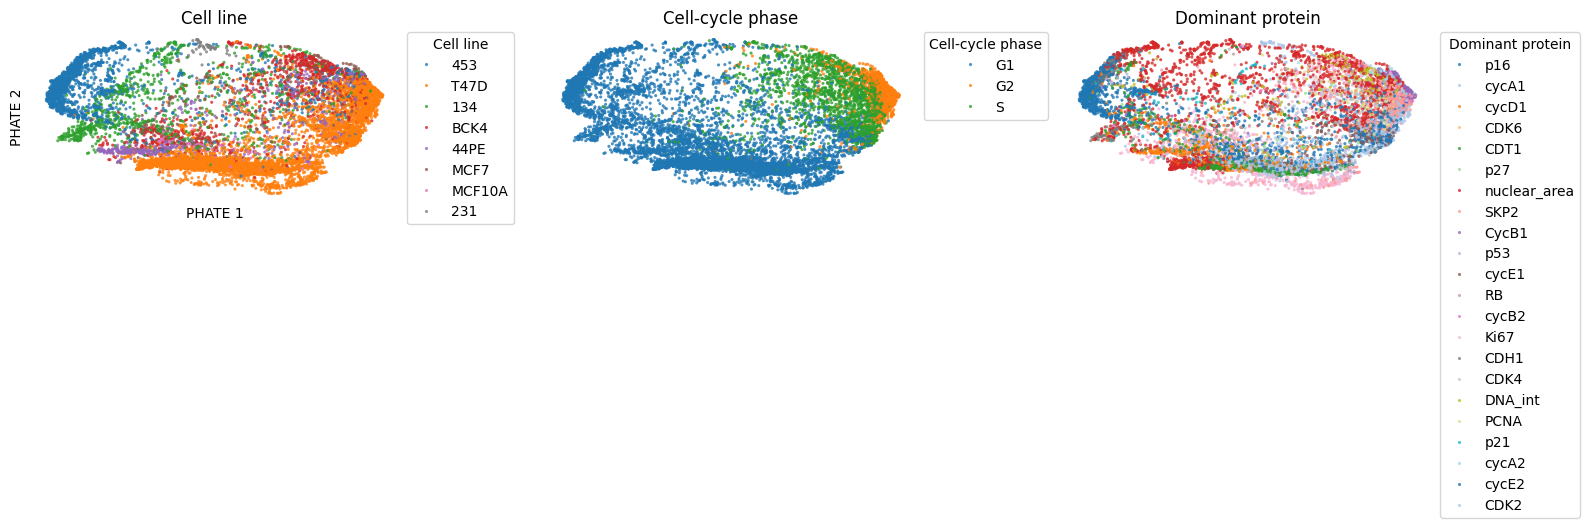

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.despine(top=True, right=True, left=True, bottom=True)
dot_size = 5

configs = [
    ("cell_line", "Cell line", {}),
    ("phase", "Cell-cycle phase", {}),
    ("dominant_protein", "Dominant protein", {"palette": "tab20"}),
]

for ax, (col, title, kw) in zip(axes, configs):
    sns.scatterplot(
        data=phate_df, x="PHATE 1", y="PHATE 2", hue=col,
        s=dot_size, linewidth=0, alpha=0.8, ax=ax, **kw,
    )
    ax.set_title(title)
    ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].set_xlabel("PHATE 1")
axes[0].set_ylabel("PHATE 2")
for ax in axes[1:]:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

PHATE embeds each cell into two dimensions that preserve the manifold structure of the control-referenced protein measurements, so nearby points have similar protein profiles. Cell line shows how strongly the lines separate under Dinaciclib after control referencing; cell-cycle phase reveals the G1 $\to$ S $\to$ G2 progression; dominant protein labels each cell by its highest-scoring marker.

---

## 2. Tensor decomposition:

We model our data as a three-way tensor $\mathcal{X} \in \mathbb{R}^{l \times c \times p}$, with $l$ cell lines, $c$ cell-cycle phases, and $p$ proteins. Each entry $\mathcal{X}_{ijk}$ is the z-scored pseudobulk mean of the control-referenced protein $k$ in phase $j$ of cell line $i$ under Dinaciclib.

We decompose $\mathcal{X}$ via a Tucker decomposition (computed by HOSVD):

$$
\mathcal{X} \approx \mathcal{G} \times_1 L \times_2 C \times_3 P
$$

where $L \in \mathbb{R}^{l \times l_F}$, $C \in \mathbb{R}^{c \times c_F}$, $P \in \mathbb{R}^{p \times p_F}$ are orthonormal factor matrices (obtained from the SVD of each mode's unfolding), and $\mathcal{G} \in \mathbb{R}^{l_F \times c_F \times p_F}$ is the core tensor governing how factors interact across modes.

A key derived quantity is:

$$
\mathcal{F} = \mathcal{G} \times_1 L \times_2 C \in \mathbb{R}^{l \times c \times p_F}
$$

which encodes the strength of each latent protein-factor across all cell-line-phase combinations in the original coordinate system. We keep the cell-line and phase ranks at their maximum ($l_F = l$, $c_F = c$) and truncate only the protein rank to $p_F$.

### 2.1 Pseudobulking:

Similar to Mitchel et al. (2025), we perform pseudobulking, averaging proteins within each (cell line, cell-cycle-phase) group and z-scoring across all groups to obtain the tensor $\mathcal{X}$.

In [8]:
cct = CCTensor(adata, treatment_col="cell_line", treatments=CELL_LINES, cc_phases=phases, proteins=proteins)
cct.pseudobulk()
print(f"Pseudobulk tensor shape: {cct.tensor.shape}")

Pseudobulk tensor shape: (8, 3, 22)


### 2.2 Protein rank selection:

To choose $p_F$, we sweep protein ranks from 1 to $p$ (keeping $l_F = l$ and $c_F = c$ fixed), reconstruct the tensor at each rank, and compute the relative Frobenius error $\|\hat{\mathcal{X}} - \mathcal{X}\|_F / \|\mathcal{X}\|_F$. The optimal rank is identified by the maximum gap between the error curve and a linear interpolation from rank 1 to rank $p$ (an elbow heuristic).

Maximum difference at step 9: 0.28912279861280465


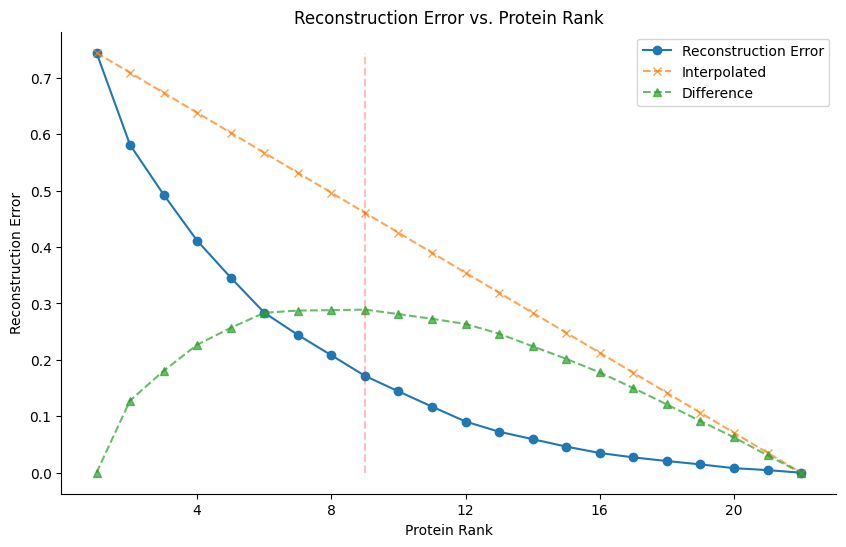

9

In [9]:
cct.determine_rank()

The elbow heuristic above gives a data-driven rank. We keep 4 latent protein-factors, matching the per-cell-line notebooks, so that factors can be compared across the two analyses.

In [10]:
n_protein_factors = 4
truncation_rank = [len(CELL_LINES), len(phases), n_protein_factors]
cct.set_tensor_decompositions(truncation_rank=truncation_rank)


In [11]:
viz = CCTensorViz(cct, mode0_label="Cell line")

---

## 3. Tensor diagnostics:

Singular value spectrum:

For each mode $k \in \{1, 2, 3\}$, we unfold $\mathcal{X}$ into a matrix $\mathbf{X}_{(k)}$ and compute its singular values $\sigma_1 \geq \sigma_2 \geq \dots$. These are the same singular values that the HOSVD uses to construct the factor matrices. The cumulative explained variance $\sum_{i=1}^{r} \sigma_i^2 \big/ \sum_i \sigma_i^2$ shows how many components are needed to capture most of the variation along each mode.

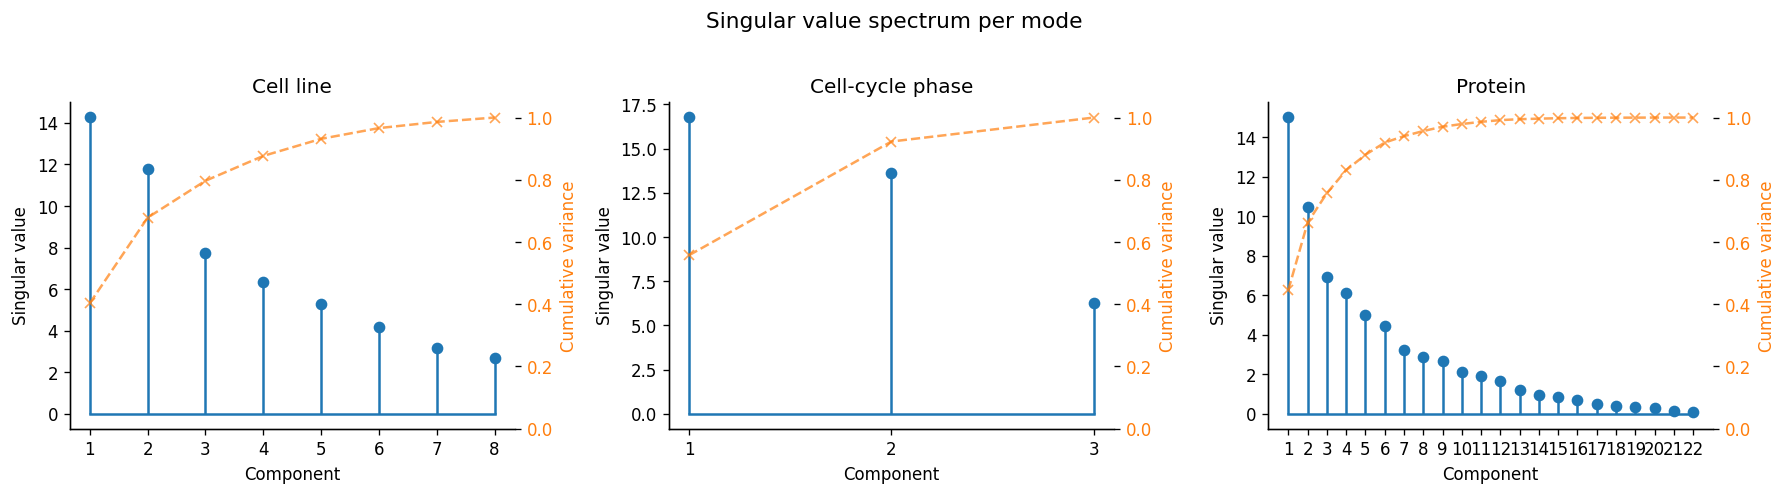

In [12]:
viz.singular_value_spectrum();

The cell-line and phase modes have as many components as they have categories, and are kept at full rank. The protein mode has 22 components; the cumulative curve shows how much variance the first $p_F = 4$ retain.

---

## 4. Latent factors:

### 4.1 Protein loadings:

The protein factor matrix $P \in \mathbb{R}^{p \times p_F}$ has one column per latent protein-factor. Entry $P_{kf}$ gives the weight of protein $k$ on factor $f$. Because the columns are orthonormal, each factor defines a direction in protein space; proteins with the same sign co-vary along that direction, and opposite signs indicate anti-correlation. The overall sign of a column is arbitrary (flipping a factor and its corresponding core slice leaves the reconstruction unchanged).

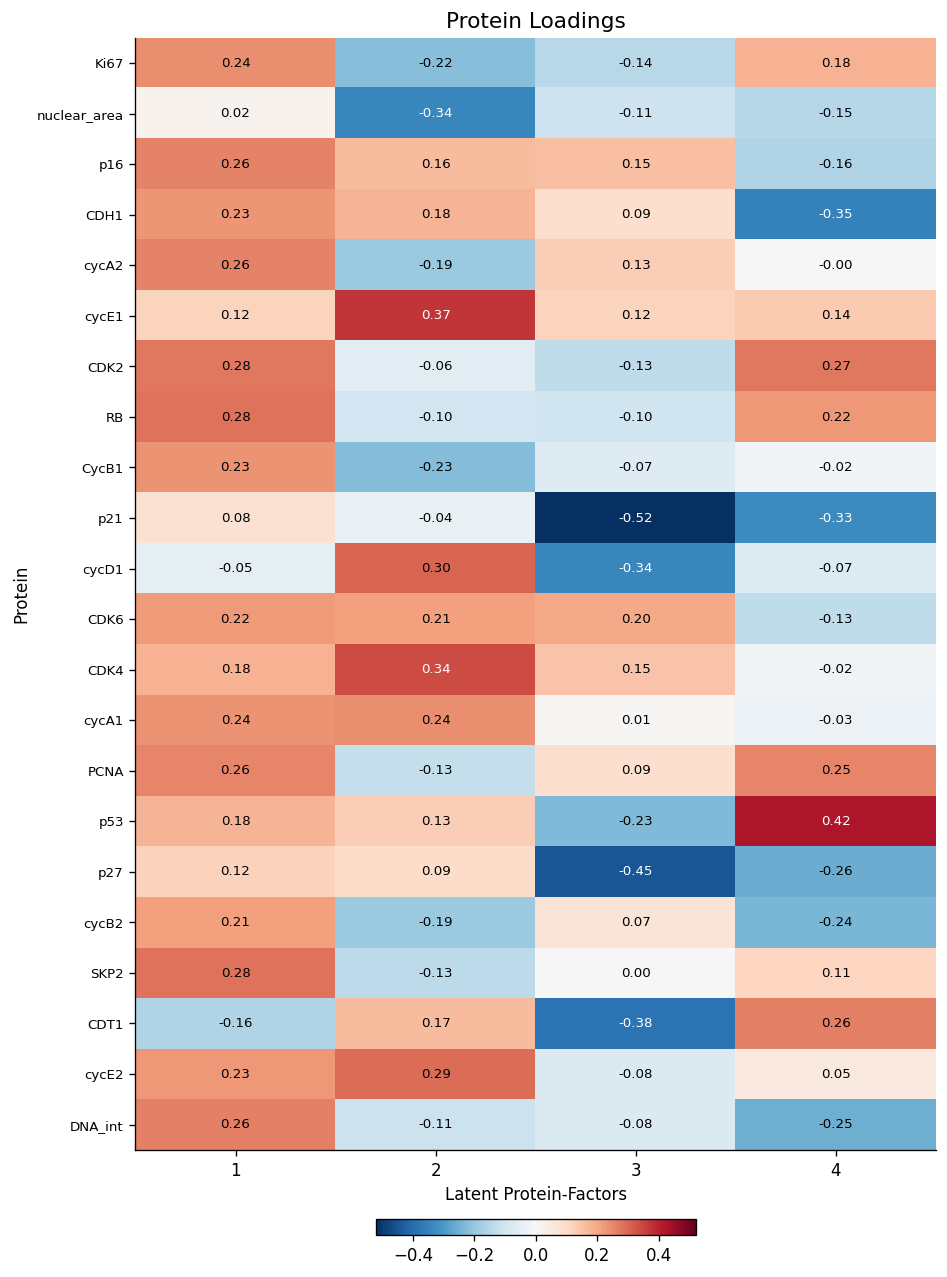

In [13]:
viz.protein_loadings_heatmap();

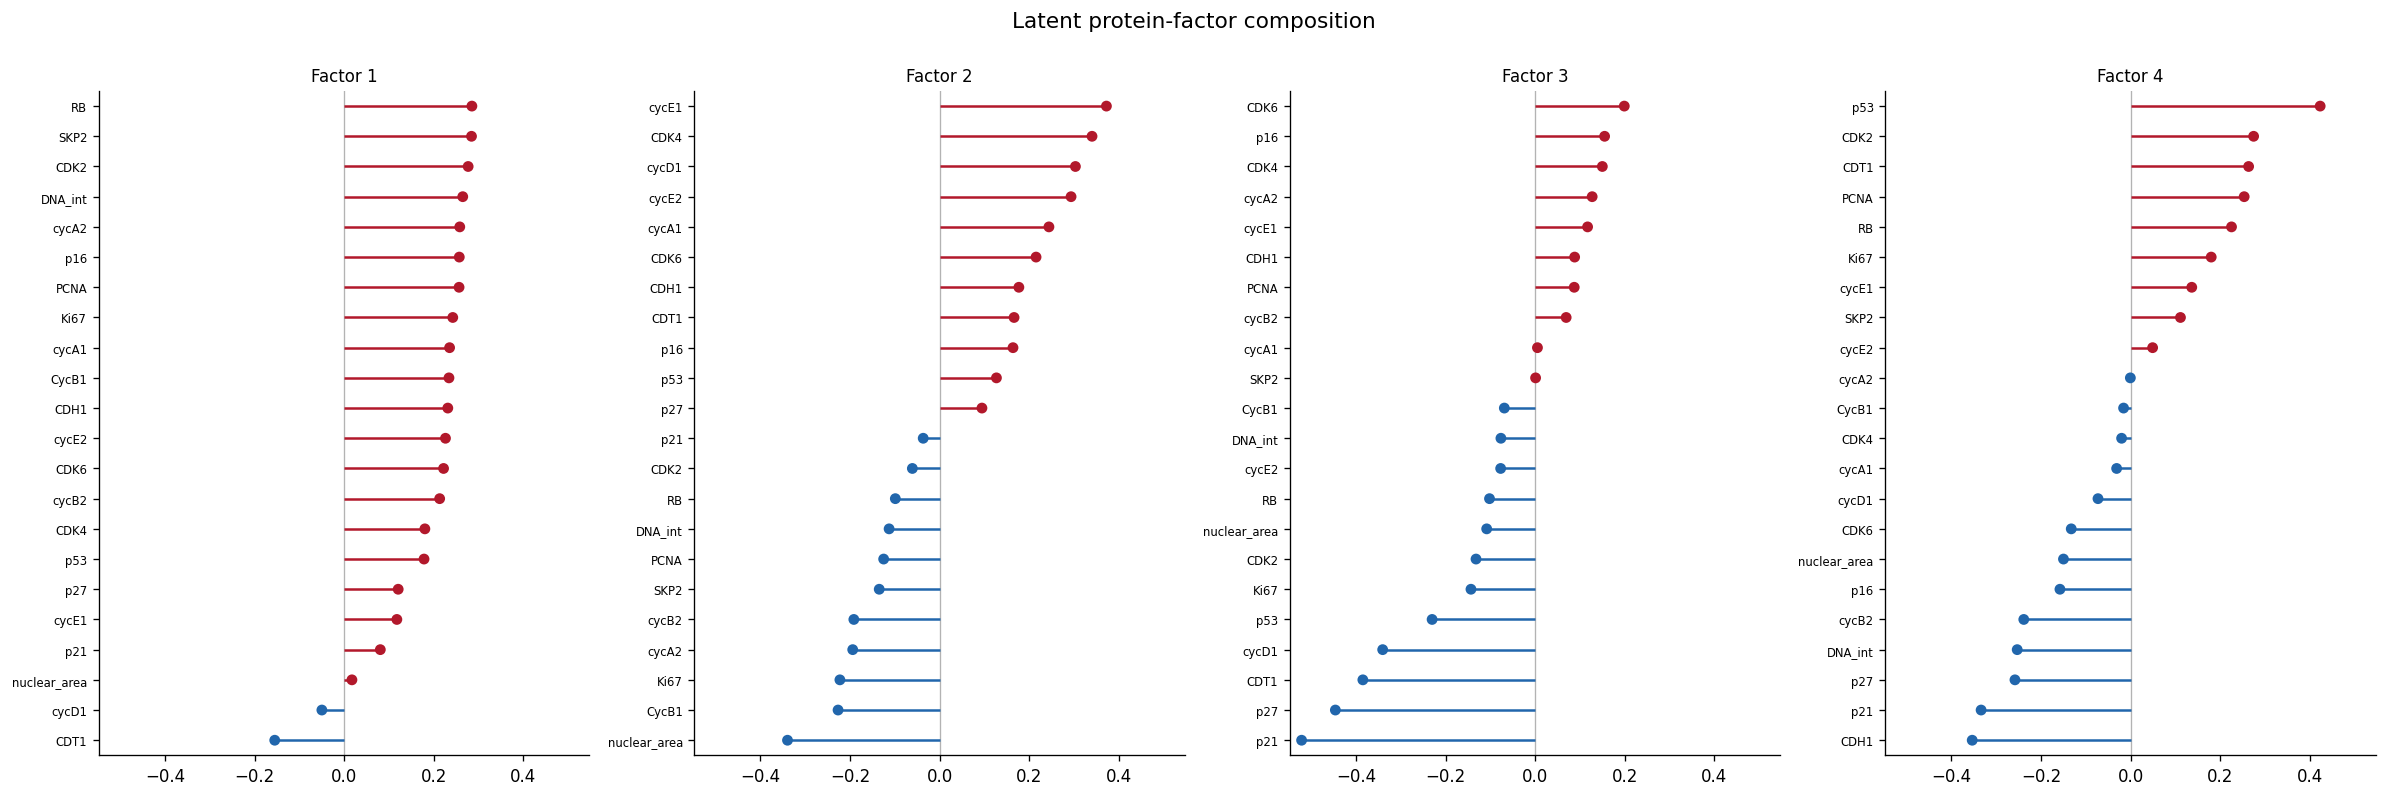

In [14]:
viz.protein_loadings_lollipop();

The lollipop charts show the same loading values sorted by magnitude within each factor. This makes it easy to identify the dominant contributors (the proteins at the extremes) and the direction of their contribution.

### 4.2 Cell-line loadings:

The cell-line factor matrix $L \in \mathbb{R}^{l \times l_F}$ captures how each cell line loads onto the latent cell-line-factors. Because the cell-line mode is kept at full rank ($l_F = l$), this matrix is a square orthonormal basis; its entries show the coordinates of each cell line in the rotated factor space.

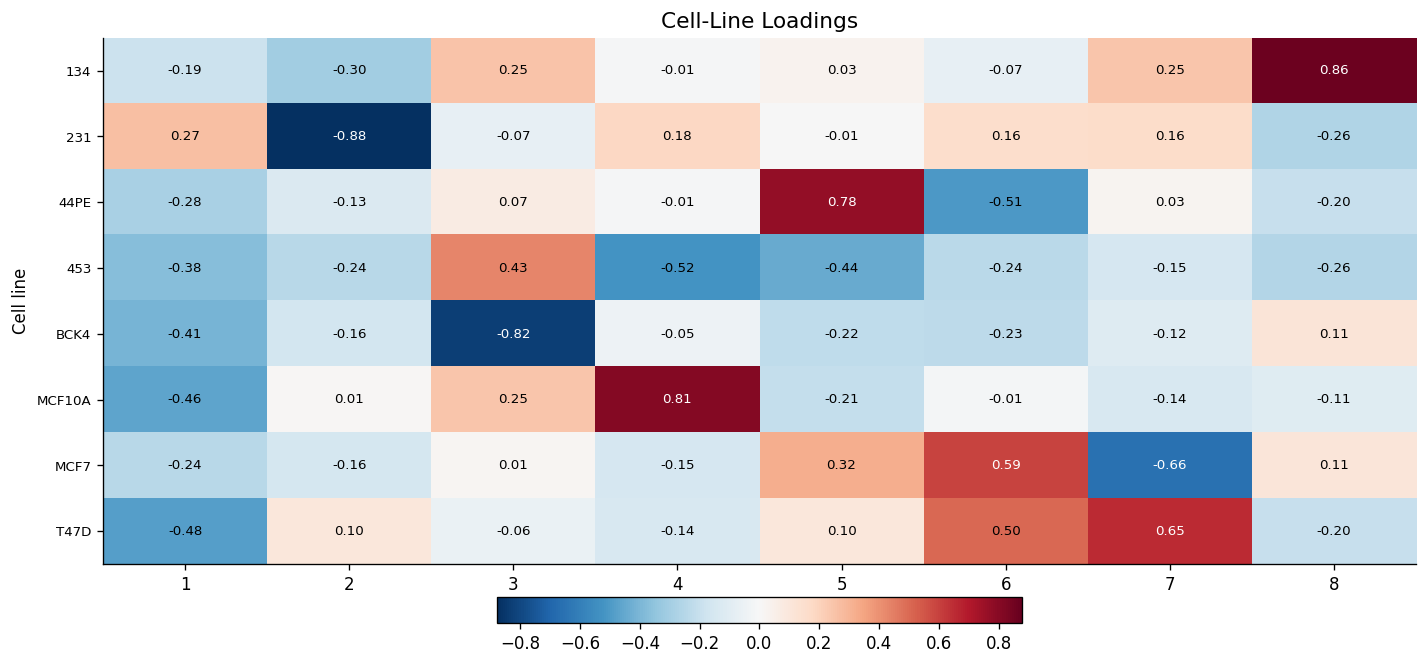

In [15]:
viz.treatment_loadings_heatmap();

### 4.3 Latent factor clustering:

To understand which proteins behave similarly in latent factor space, we compute the cosine similarity between all pairs from their respective factor matrices. For proteins, the Gram matrix $\hat{P}\hat{P}^\top$ (where $\hat{P}$ is row-normalized) gives the pairwise cosine similarity. We use Agglomerative clustering with average linkage on the derived distance $(1 - \text{similarity})/2$ to reveal groups of proteins with similar latent factor profiles.

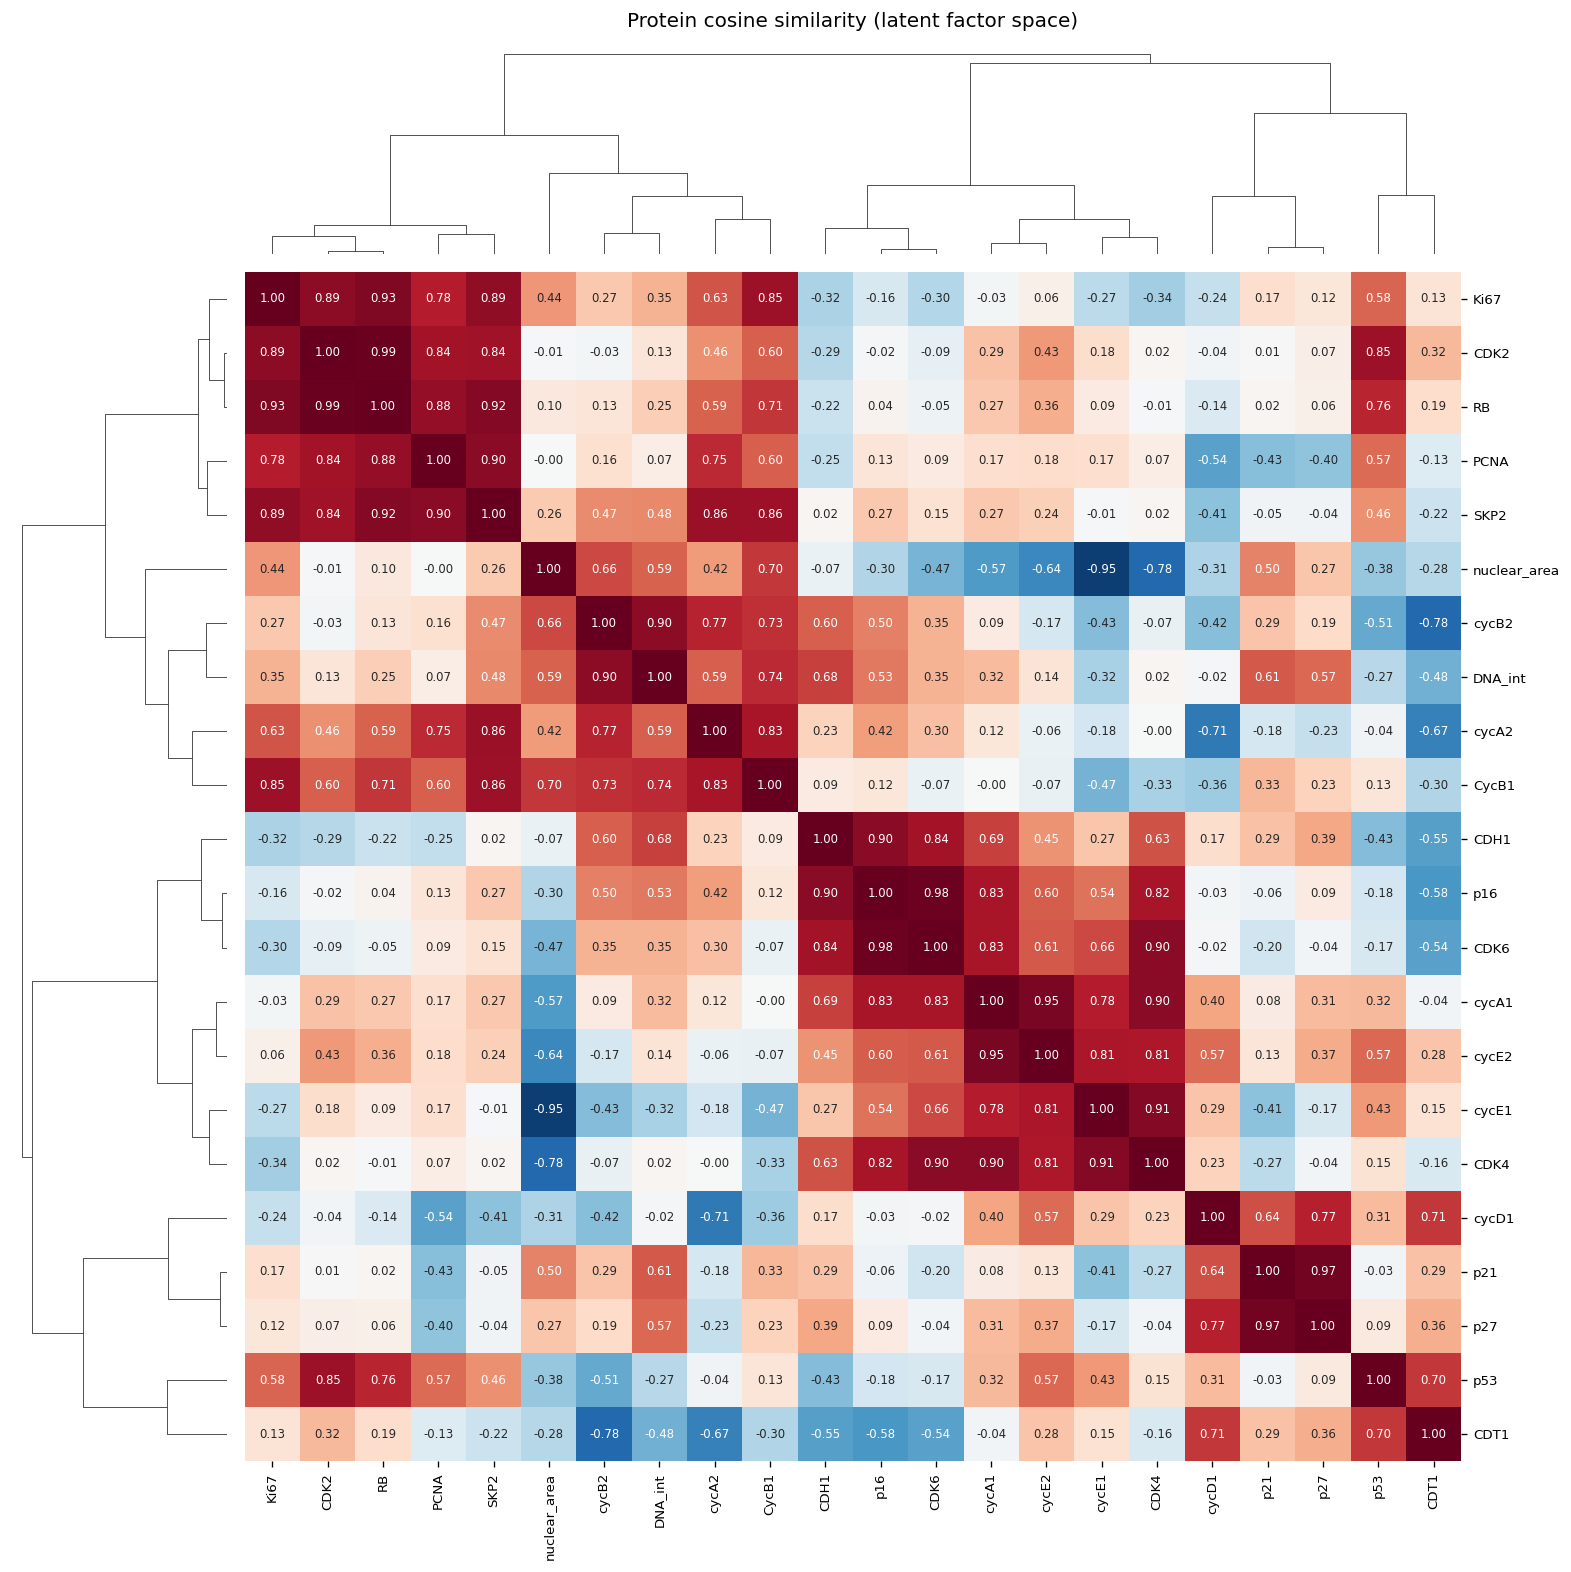

In [16]:
viz.gram_clustermap(mode="protein");

### 4.4 F slice montage:

The tensor $\mathcal{F} = \mathcal{G} \times_1 L \times_2 C \in \mathbb{R}^{l \times c \times p_F}$ maps the core back into the original cell-line and phase coordinates while retaining the latent protein-factor axis. Each frontal slice $\mathcal{F}_{:,:,f}$ is an $l \times c$ matrix showing how strongly factor $f$ is expressed across all cell-line-phase combinations. Positive values mean the factor points in its "positive" direction (per the loading signs above); negative values mean it points in the opposite direction.

The per-cell-line notebooks follow this with a control-normalized montage. It is omitted here: Control is not a row of this tensor, and the control referencing is already applied to every cell in section 1.1.

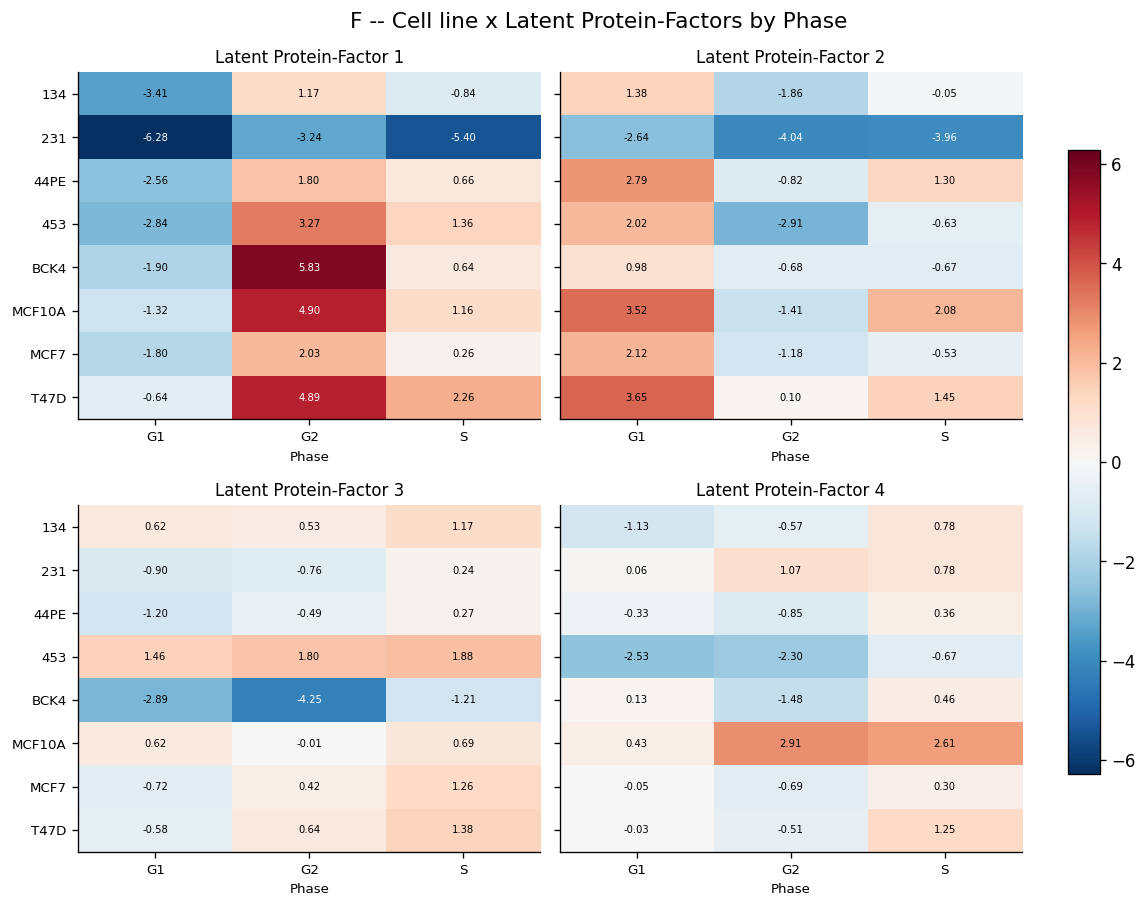

In [17]:
viz.F_slice_montage();

---

## 5. Single-cell factor projections:

The decomposition above operates on the pseudobulk tensor. To understand how the latent protein-factors manifest at the single-cell level, we project individual cells into factor space. Given a cell's control-referenced protein vector $\mathbf{x} \in \mathbb{R}^p$, we z-score it using the global mean $\boldsymbol{\mu}$ and standard deviation $\boldsymbol{\sigma}$, then project:

$$
\mathbf{s} = \left(\frac{\mathbf{x} - \boldsymbol{\mu}}{\boldsymbol{\sigma}}\right) P \in \mathbb{R}^{p_F}
$$

The resulting score $s_f$ measures how strongly cell $\mathbf{x}$ expresses the protein program defined by factor $f$.

We color the global PHATE embedding by each factor's score $s_f$. This reveals the spatial organization of each protein program across the manifold.

Computing global PHATE embedding...
Calculating PHATE...
  Running PHATE on 10000 observations and 22 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.12 seconds.
    Calculating affinities...
    Calculated affinities in 0.11 seconds.
  Calculated graph and diffusion operator in 0.23 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.28 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.42 seconds.
  Calculated landmark operator in 1.70 seconds.
  Calculating optimal t...
    Automatically selected t = 18
  Calculated optimal t in 1.08 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.24 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.23 seconds.
Calculated PHATE in 4.75 seconds.


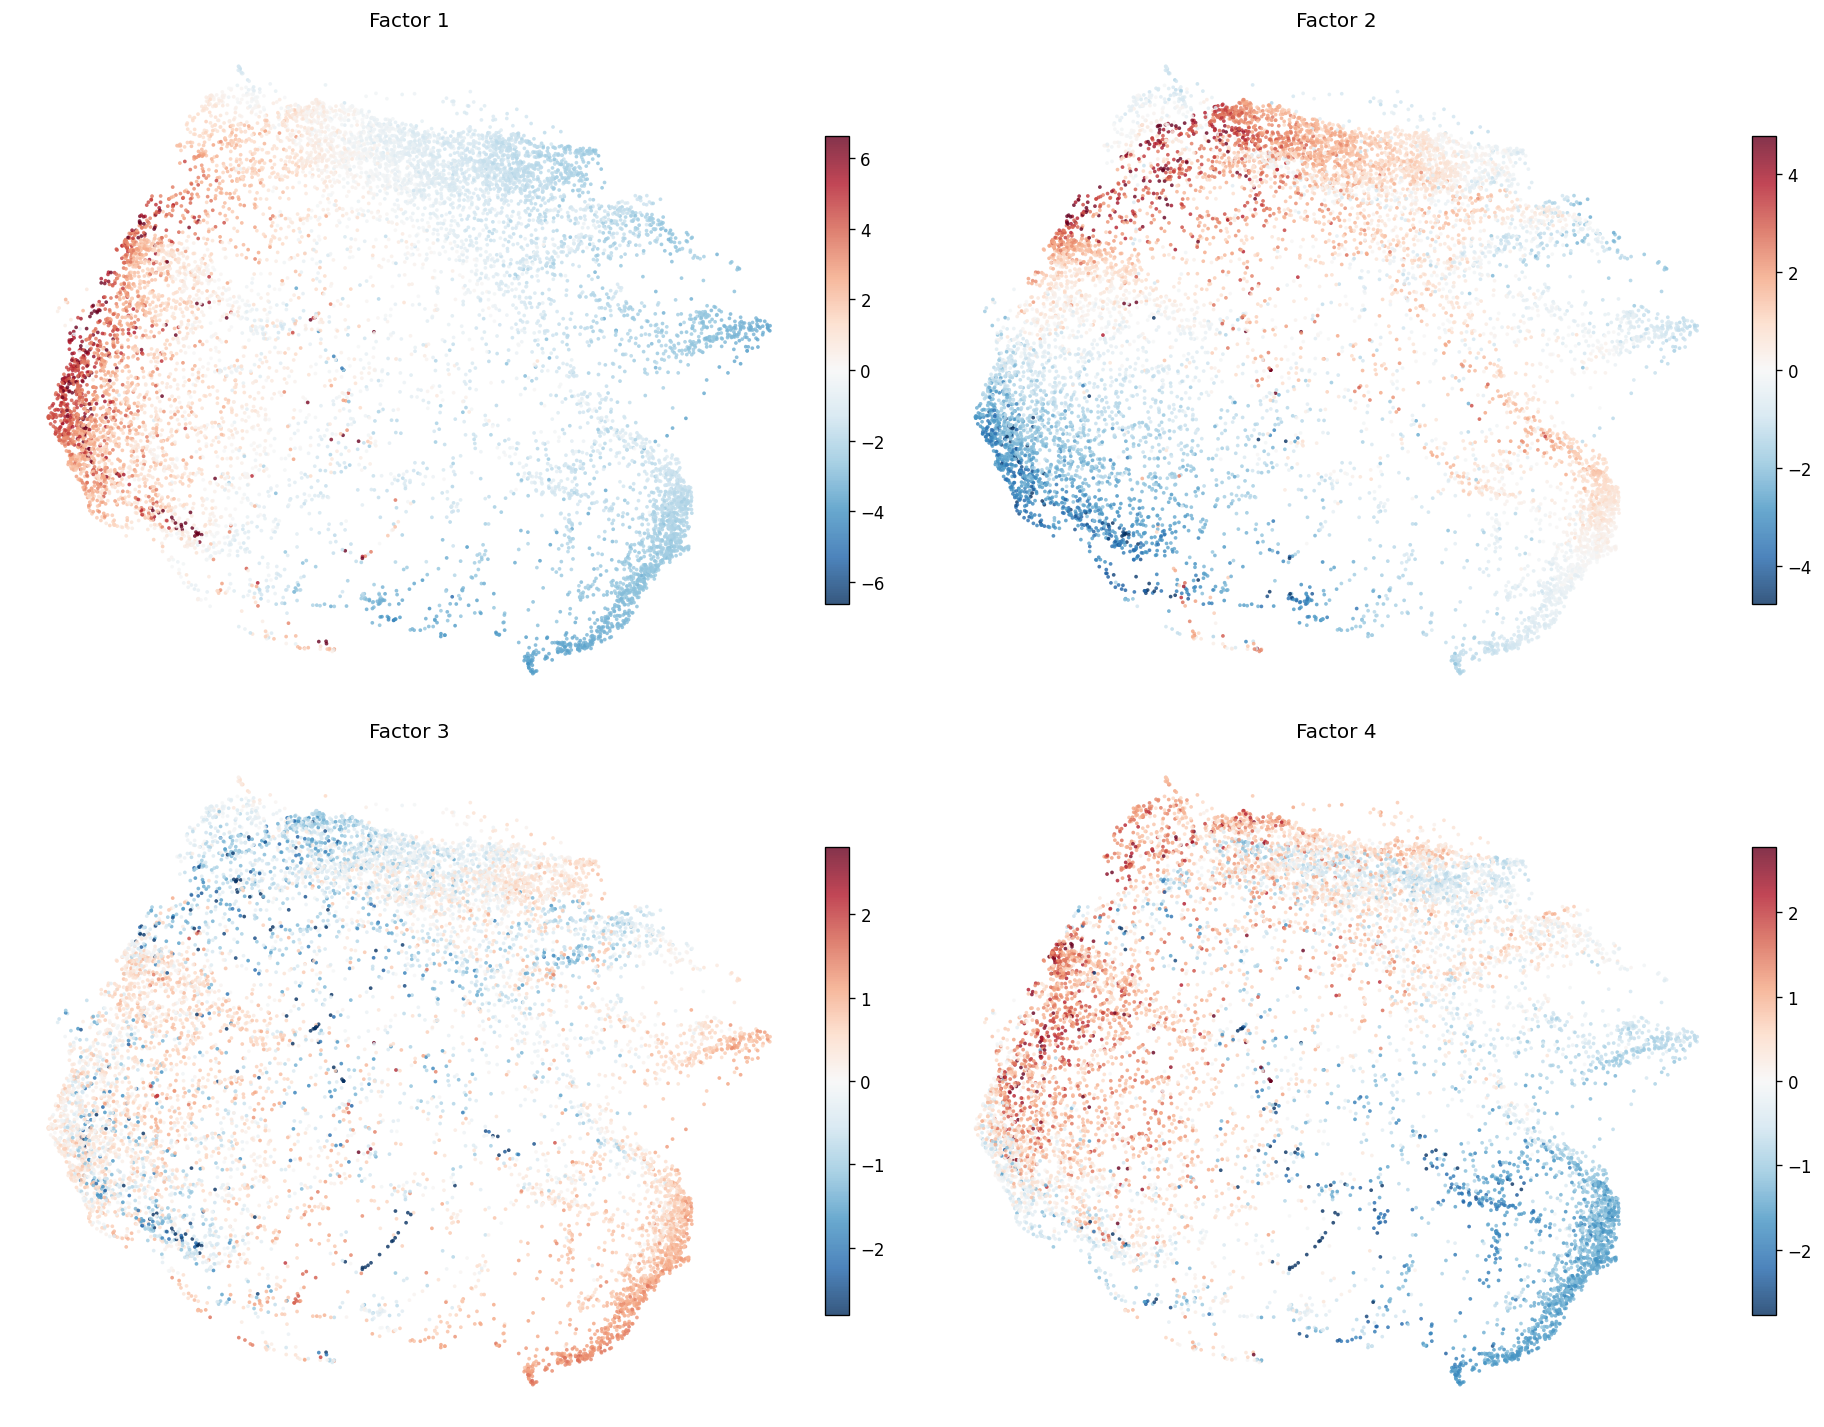

In [18]:
viz.phate_factor_scores();

---

## 6. Per-cell-line analysis:

### 6.1 Factor scores by cell line:

For each cell, we project its z-scored protein vector onto the protein factor matrix to obtain factor scores $s_f = \mathbf{z}^\top \mathbf{p}_f$. The violins show these scores grouped by cell line and colored by cell-cycle phase. Positive scores indicate alignment with the factor direction; negative scores indicate opposition. This shows which protein programs each cell line expresses under Dinaciclib.


Computing per-cell-line PHATE embeddings...
    SGD-MDS may not have converged: stress changed by 3.3% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -1.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by 1.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -2.8% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -1.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.


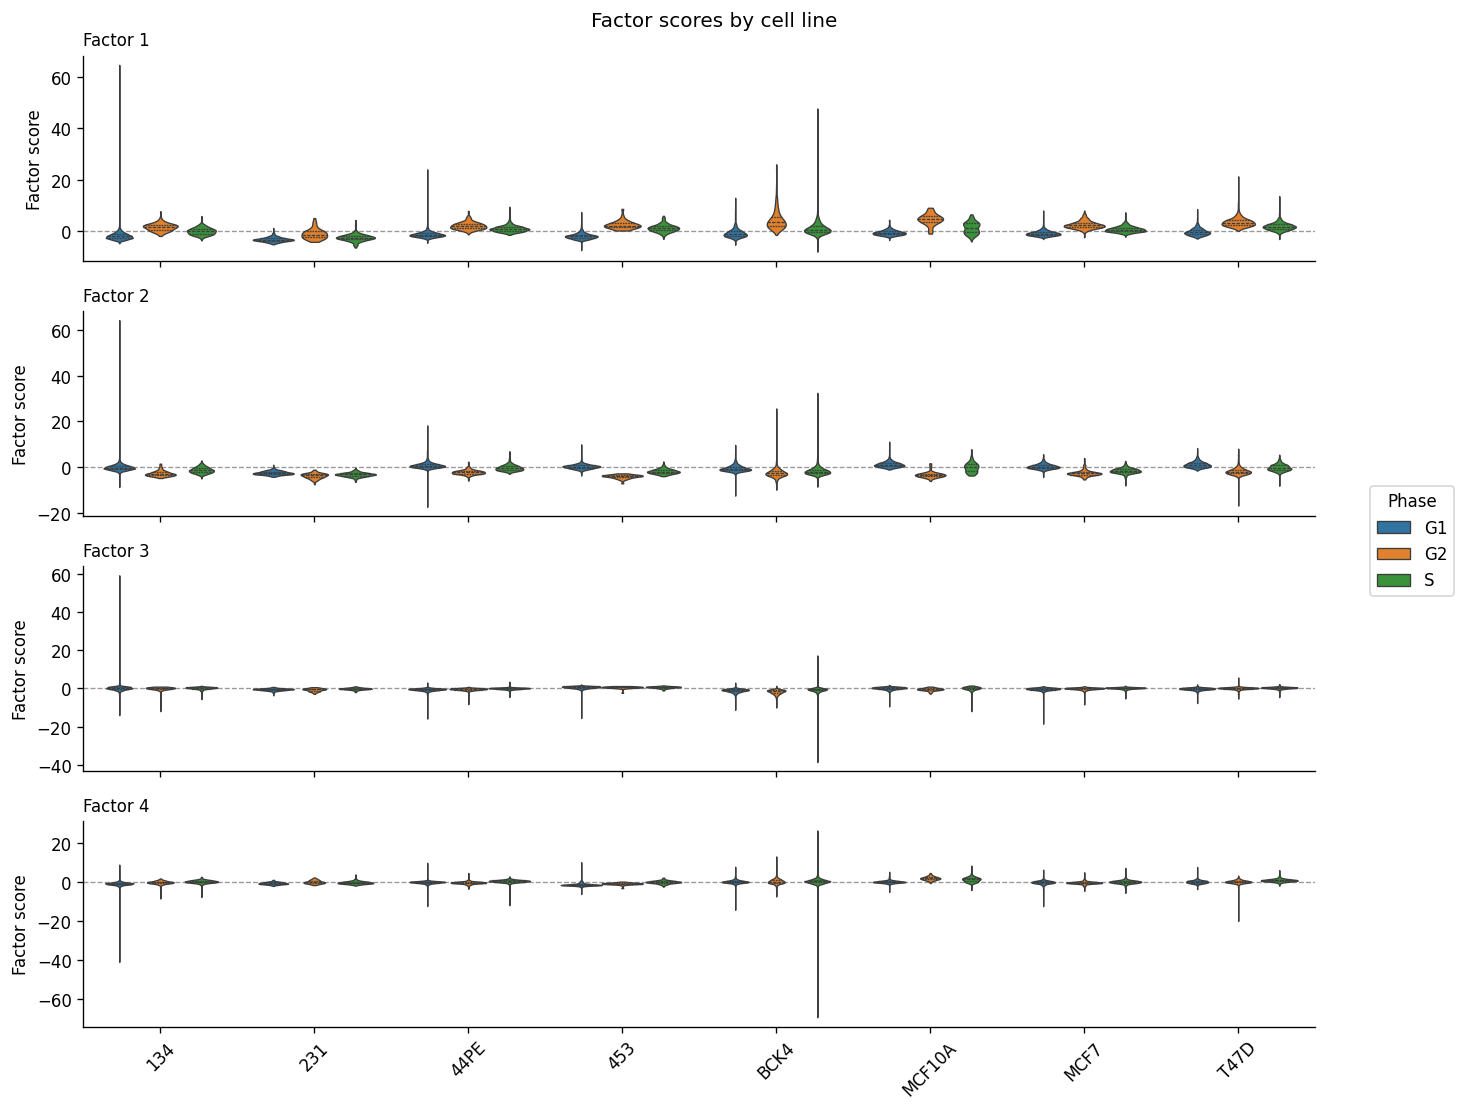

In [19]:
viz.factor_score_violins();

### 6.2 Cosine distance to factor archetypes:

For each cell with z-scored protein vector $\mathbf{z} = (\mathbf{x} - \boldsymbol{\mu})/\boldsymbol{\sigma}$ and factor scores $\mathbf{s} = \mathbf{z} P$, we compute the cosine distance to each factor's axis:

$$
d_f = 1 - \frac{s_f}{\|\mathbf{z}\|}
$$

Since the columns of $P$ are unit vectors, $s_f / \|\mathbf{z}\|$ equals the cosine of the angle between $\mathbf{z}$ and the $f$-th factor direction. A cosine distance near 0 means the cell's protein profile is closely aligned with that factor; a value near 1 means orthogonality; values above 1 indicate opposition. The violins show these distances stratified by cell line and colored by cell-cycle phase.

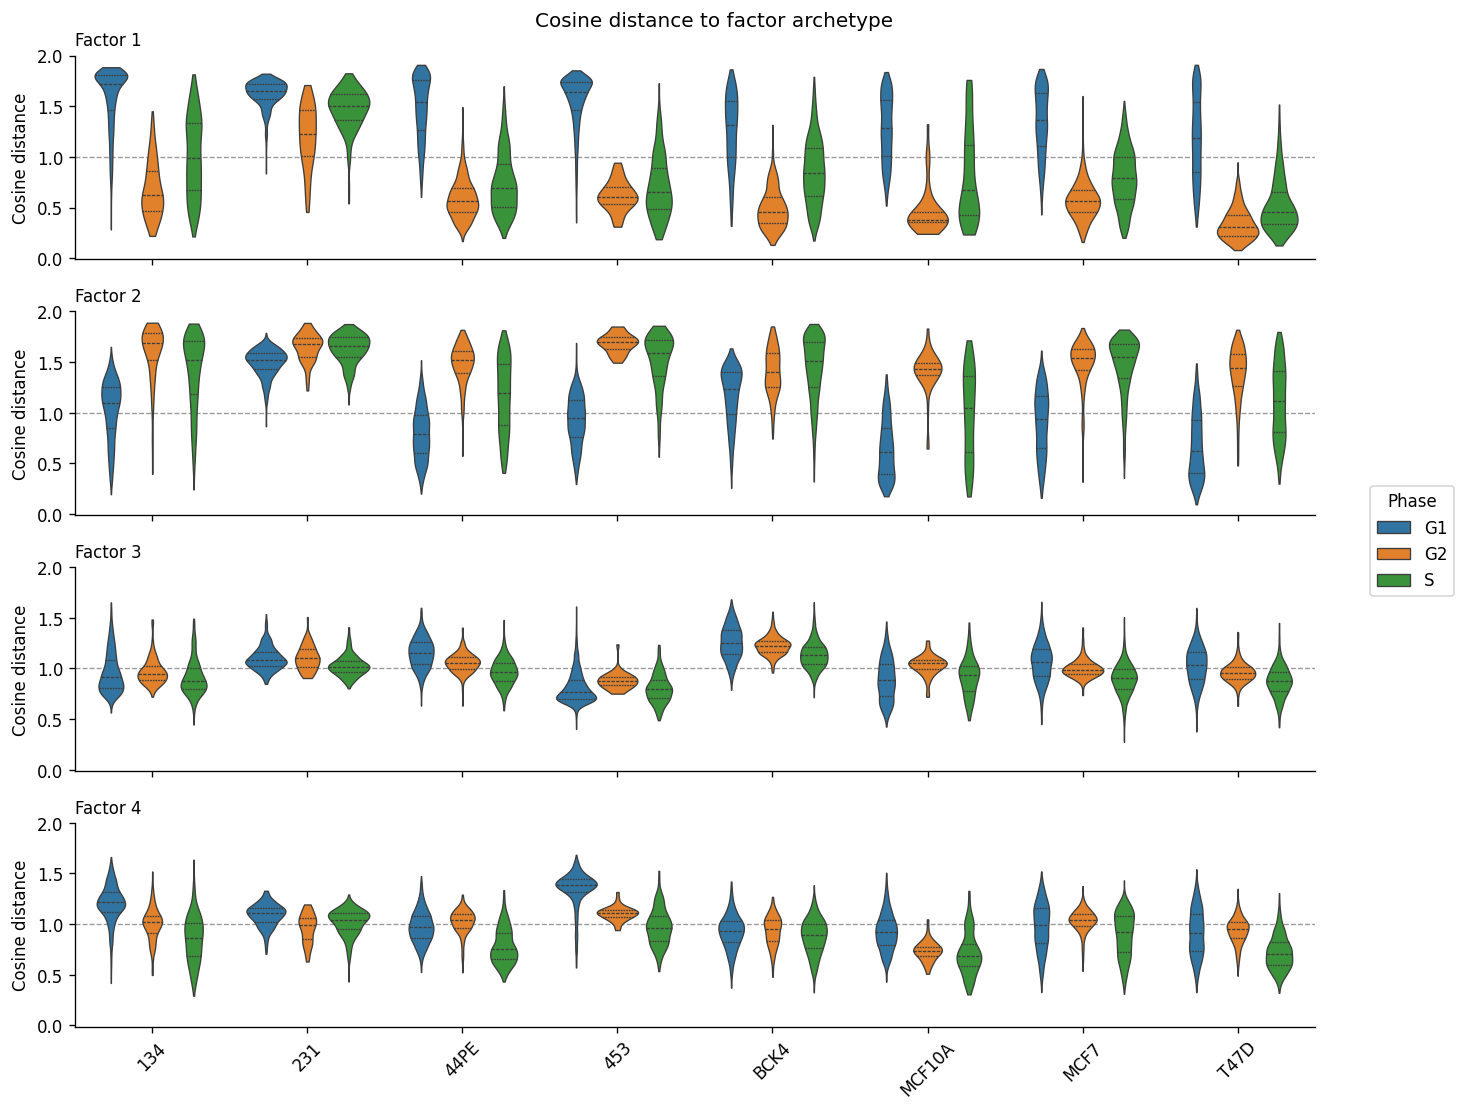

In [20]:
viz.cosine_distance_violins();

### 6.3 Per-cell-line local PHATE by latent protein-factor:

To examine how factors distribute within each cell line's population, we compute a separate PHATE embedding for each cell line (up to 3,000 cells per cell line, z-scored and embedded independently). Each panel is colored by the corresponding factor score $s_f$.

Contour lines indicate the boundaries of each cell-cycle phase (G1 in green, S in orange, G2 in red), estimated via kernel density. Phases with fewer than 15 cells in a panel get no contour.

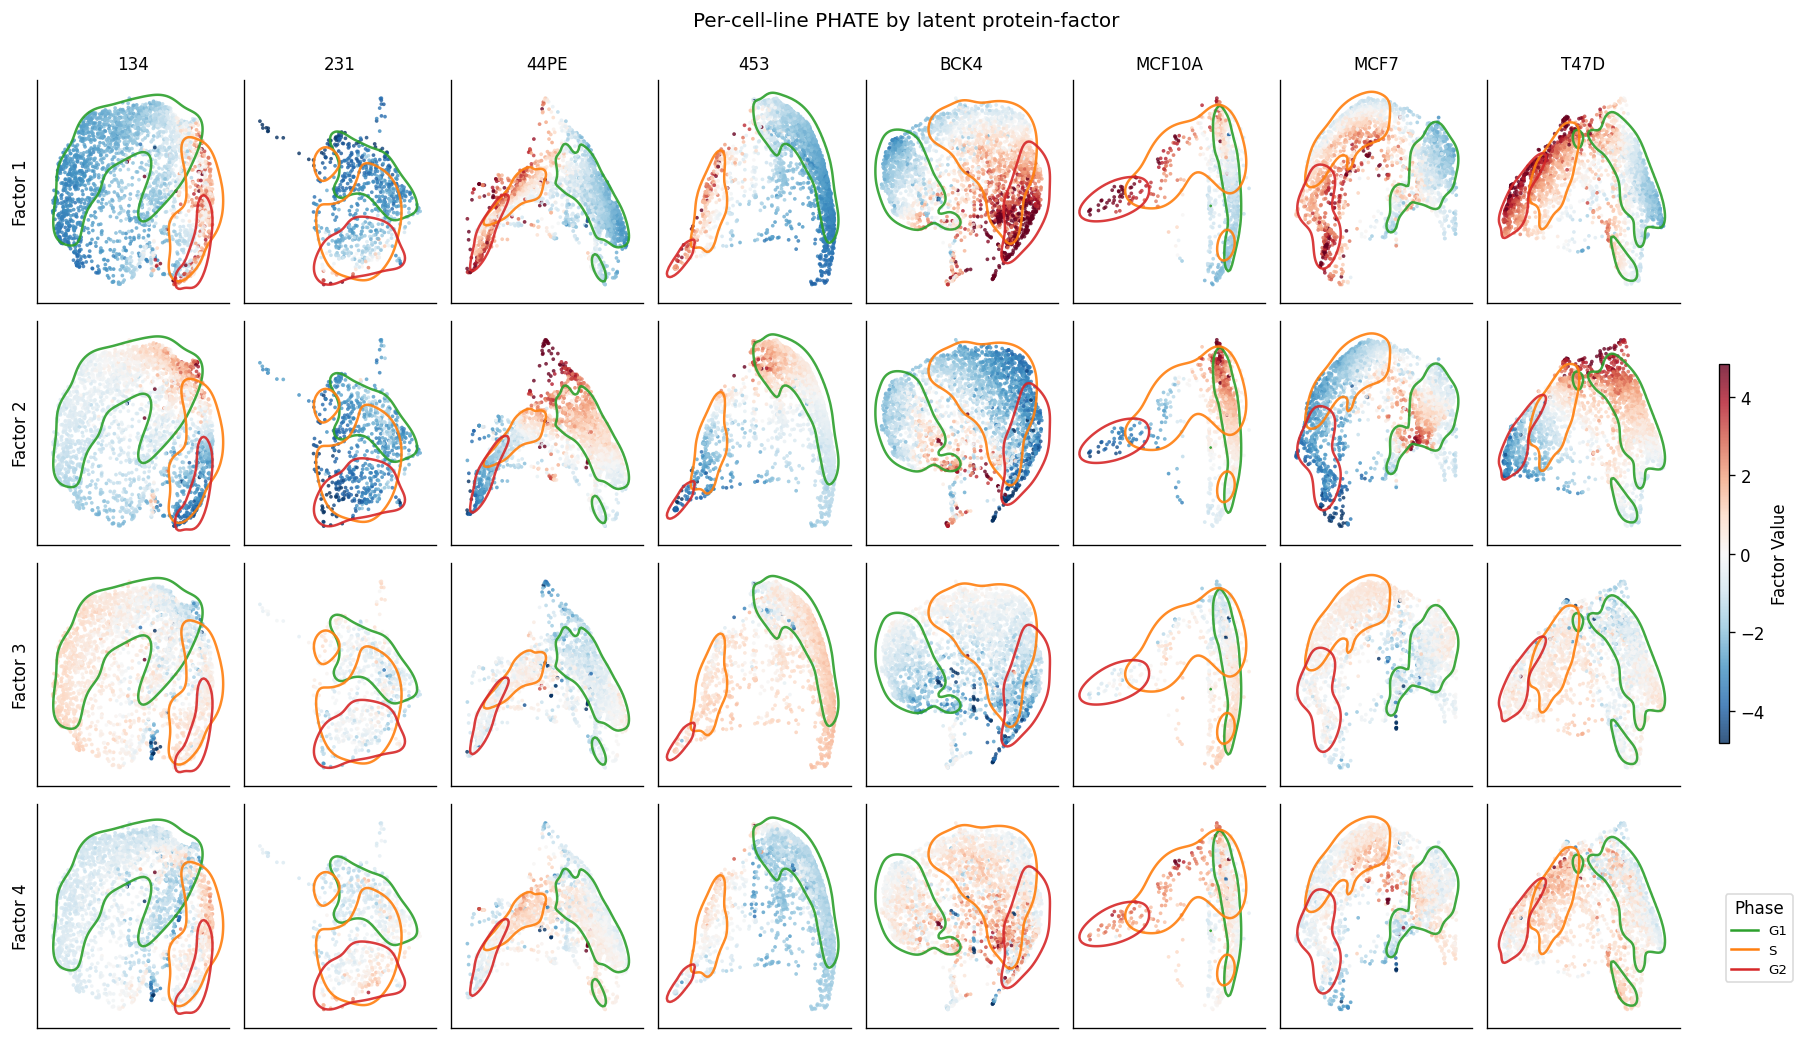

In [21]:
viz.phate_local_by_factor(show_phase_contours=True);

### 6.4 Per-cell-line global PHATE by latent protein-factor:

Same layout as above, but using the shared global PHATE coordinates (masked by cell line). This sacrifices within-line resolution but enables direct spatial comparison across cell lines: cells in the same position across panels occupy the same region of the global manifold.

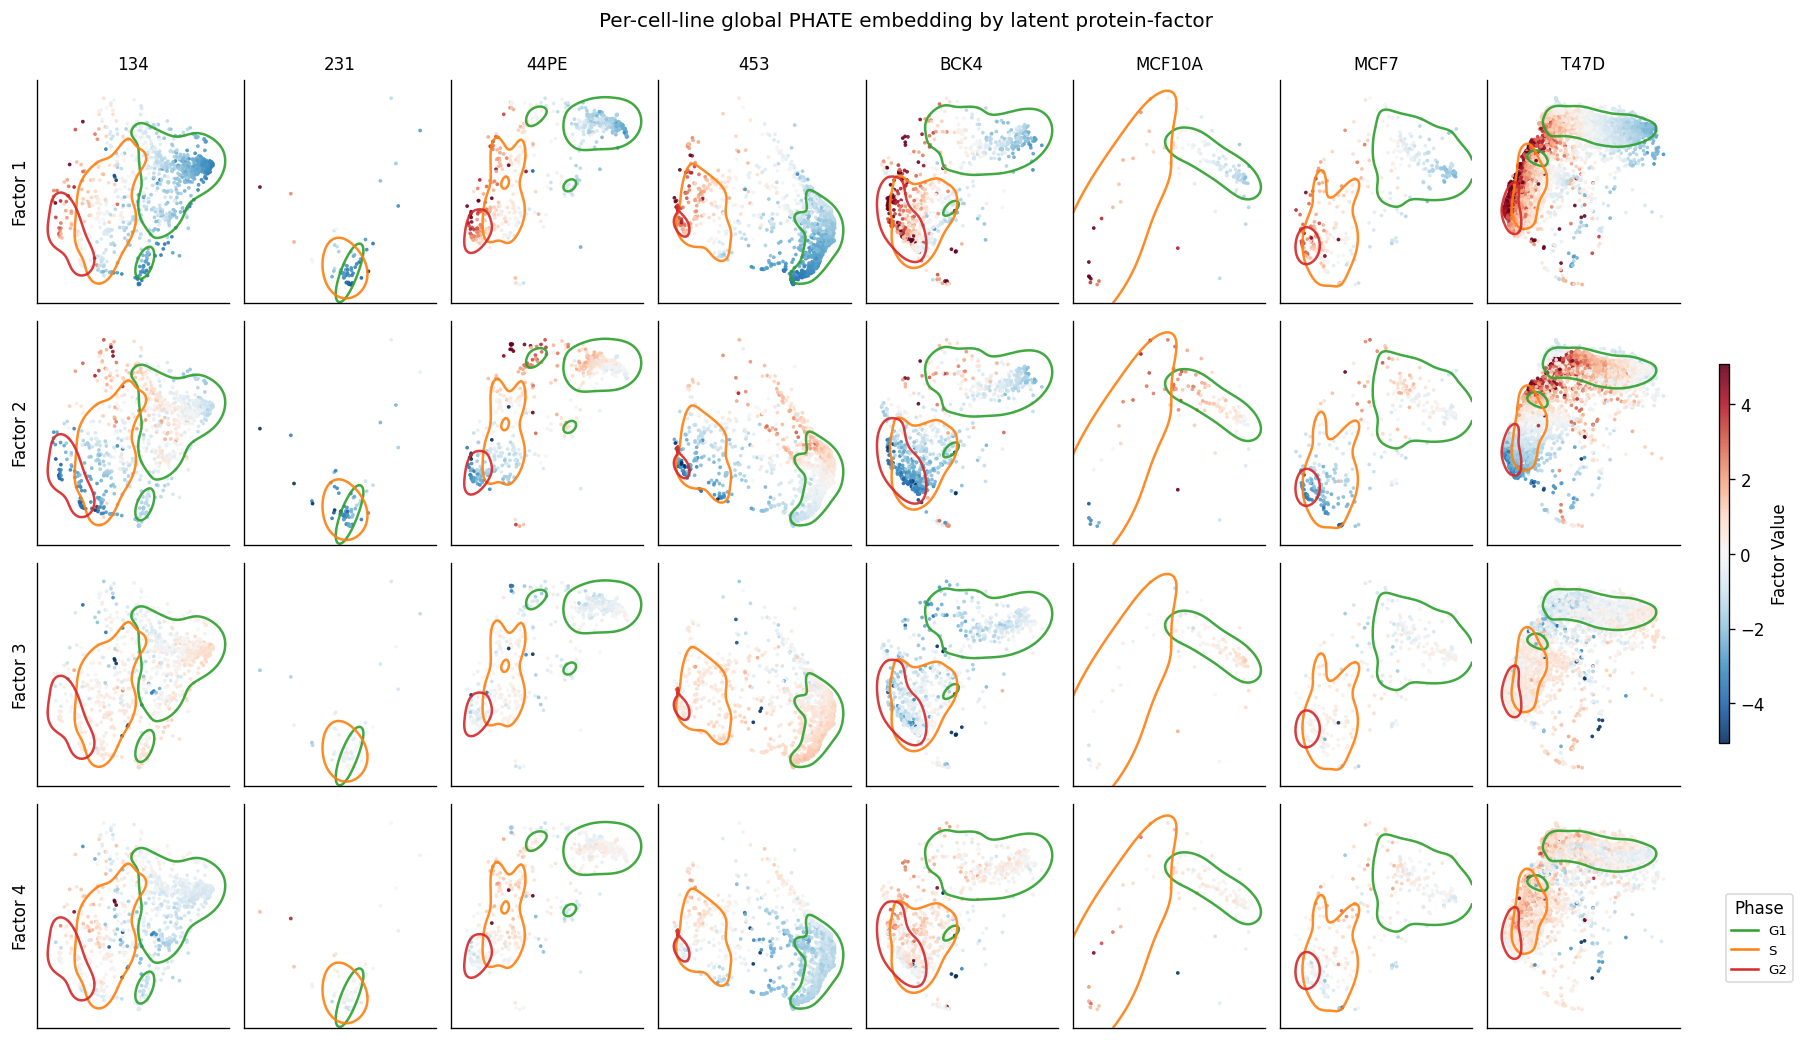

In [22]:
viz.phate_global_by_factor(show_phase_contours=True);

---

## 7. Pseudotime analysis:

The tensor decomposition and per-cell-line analyses above use discrete phase labels (G1, S, G2). To obtain a continuous view of how factor scores evolve through the cell cycle, we estimate a diffusion pseudotime (DPT) independently for each cell line.

For each cell line's subsampled cells (z-scored in the control-referenced protein space), we:

1. We build a k-nearest-neighbor graph and compute the diffusion map (which is the transition matrix of a random walk on the neighborhood graph) and get the top eigenvectors of the transition matrix on the cell graph. (via $\texttt{sc.pp.neighbors}$ and $\texttt{sc.tl.diffmap}$)
2. We then select a root cell among G1-labeled cells (the cell with the smallest first diffusion component), anchoring pseudotime at early G1.
3. Finally, we obtain DPT as the geodesic distance from the root along the diffusion map. We get a scalar $\tau \in [0, \infty)$ for each cell that increases monotonically along the dominant trajectory. (via $\texttt{sc.tl.dpt}$)

Each cell line gets one row with two panels. Left: the factor score plotted against pseudotime $\tau$, with cells colored by phase (G1, S, G2) and a LOWESS-smoothed trend in black. Right: the per-cell-line PHATE embedding colored by $\tau$, showing the spatial layout of the pseudotime ordering on the manifold. Differences between rows show how the cell lines differ in the temporal dynamics of the protein program under Dinaciclib.

Computing per-cell-line diffusion pseudotime...


/Users/kaiwycik/GitHub/Tensors and Cell Cycles/code/cc_tensor_viz.py:834: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.90, 0.99])


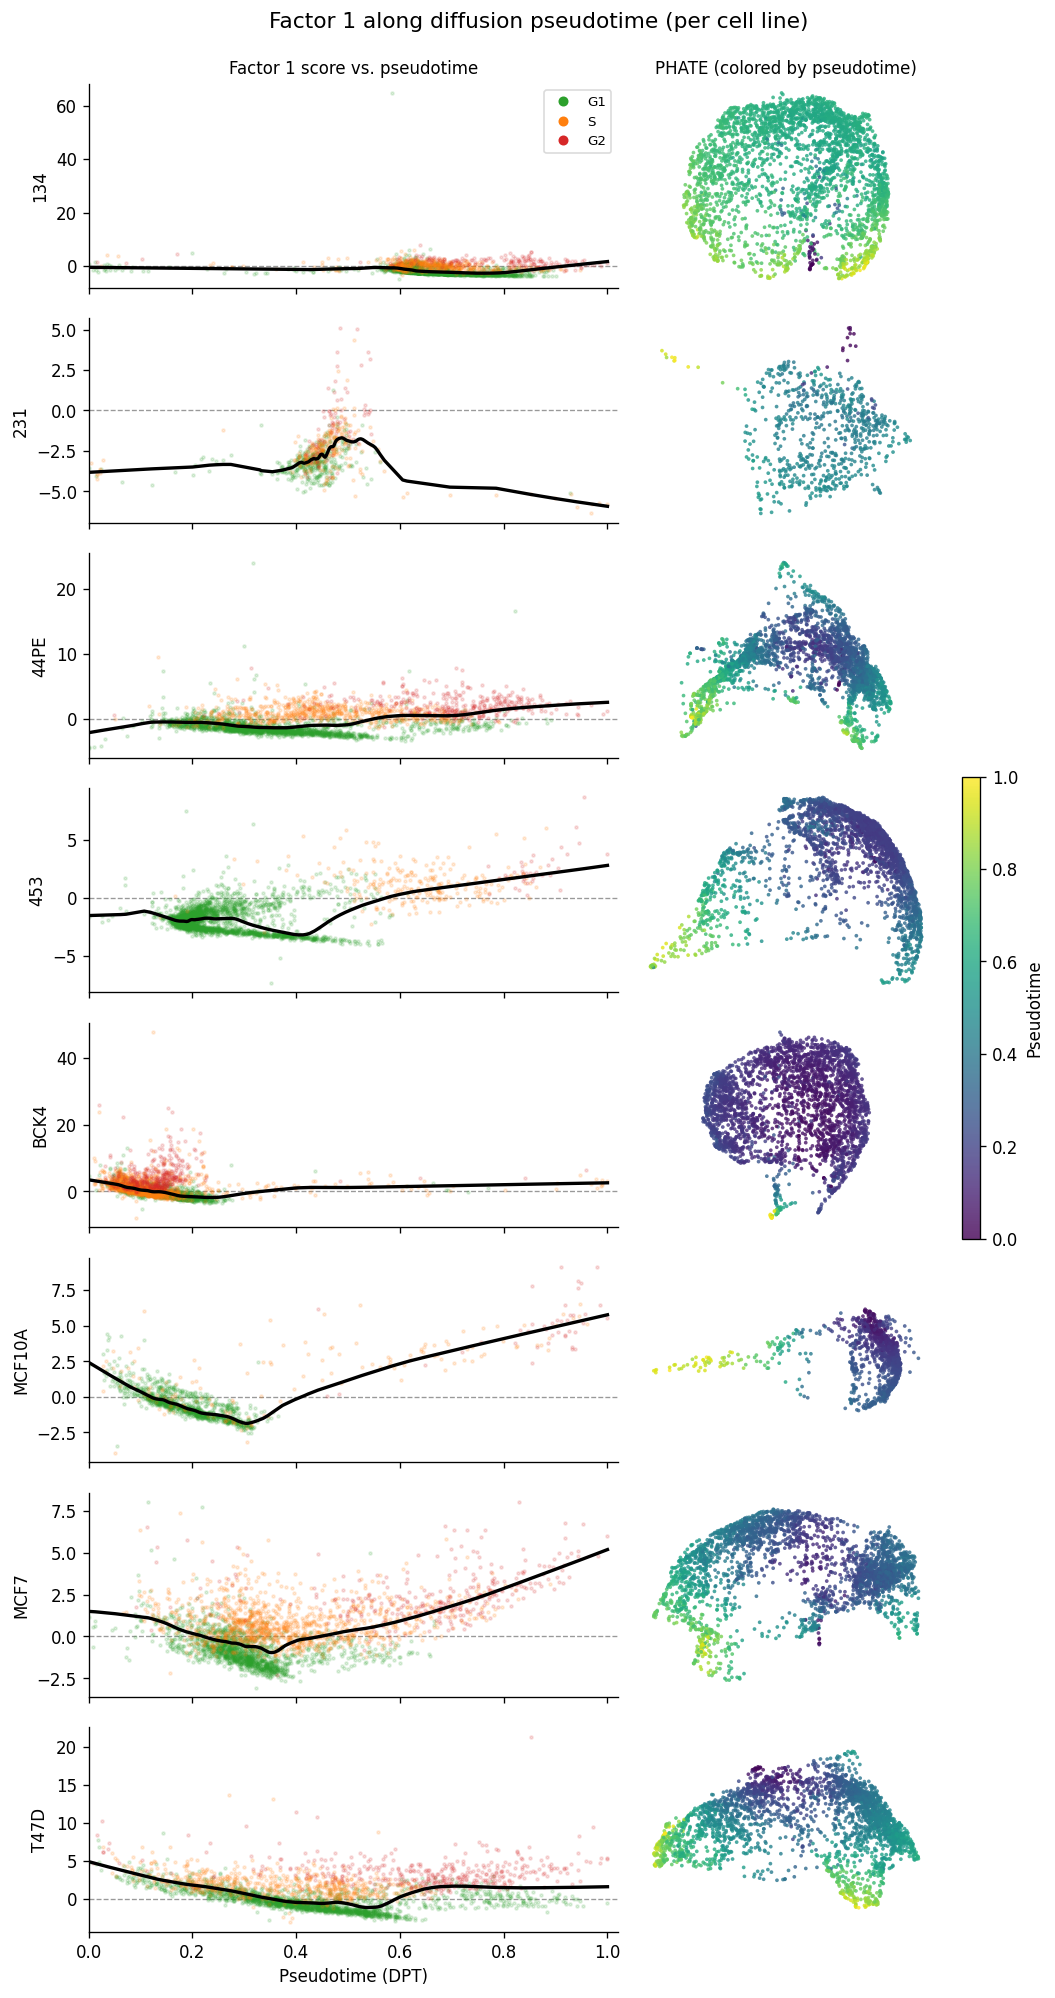

In [23]:
viz.pseudotime_factor_curves();

/Users/kaiwycik/GitHub/Tensors and Cell Cycles/code/cc_tensor_viz.py:834: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.90, 0.99])


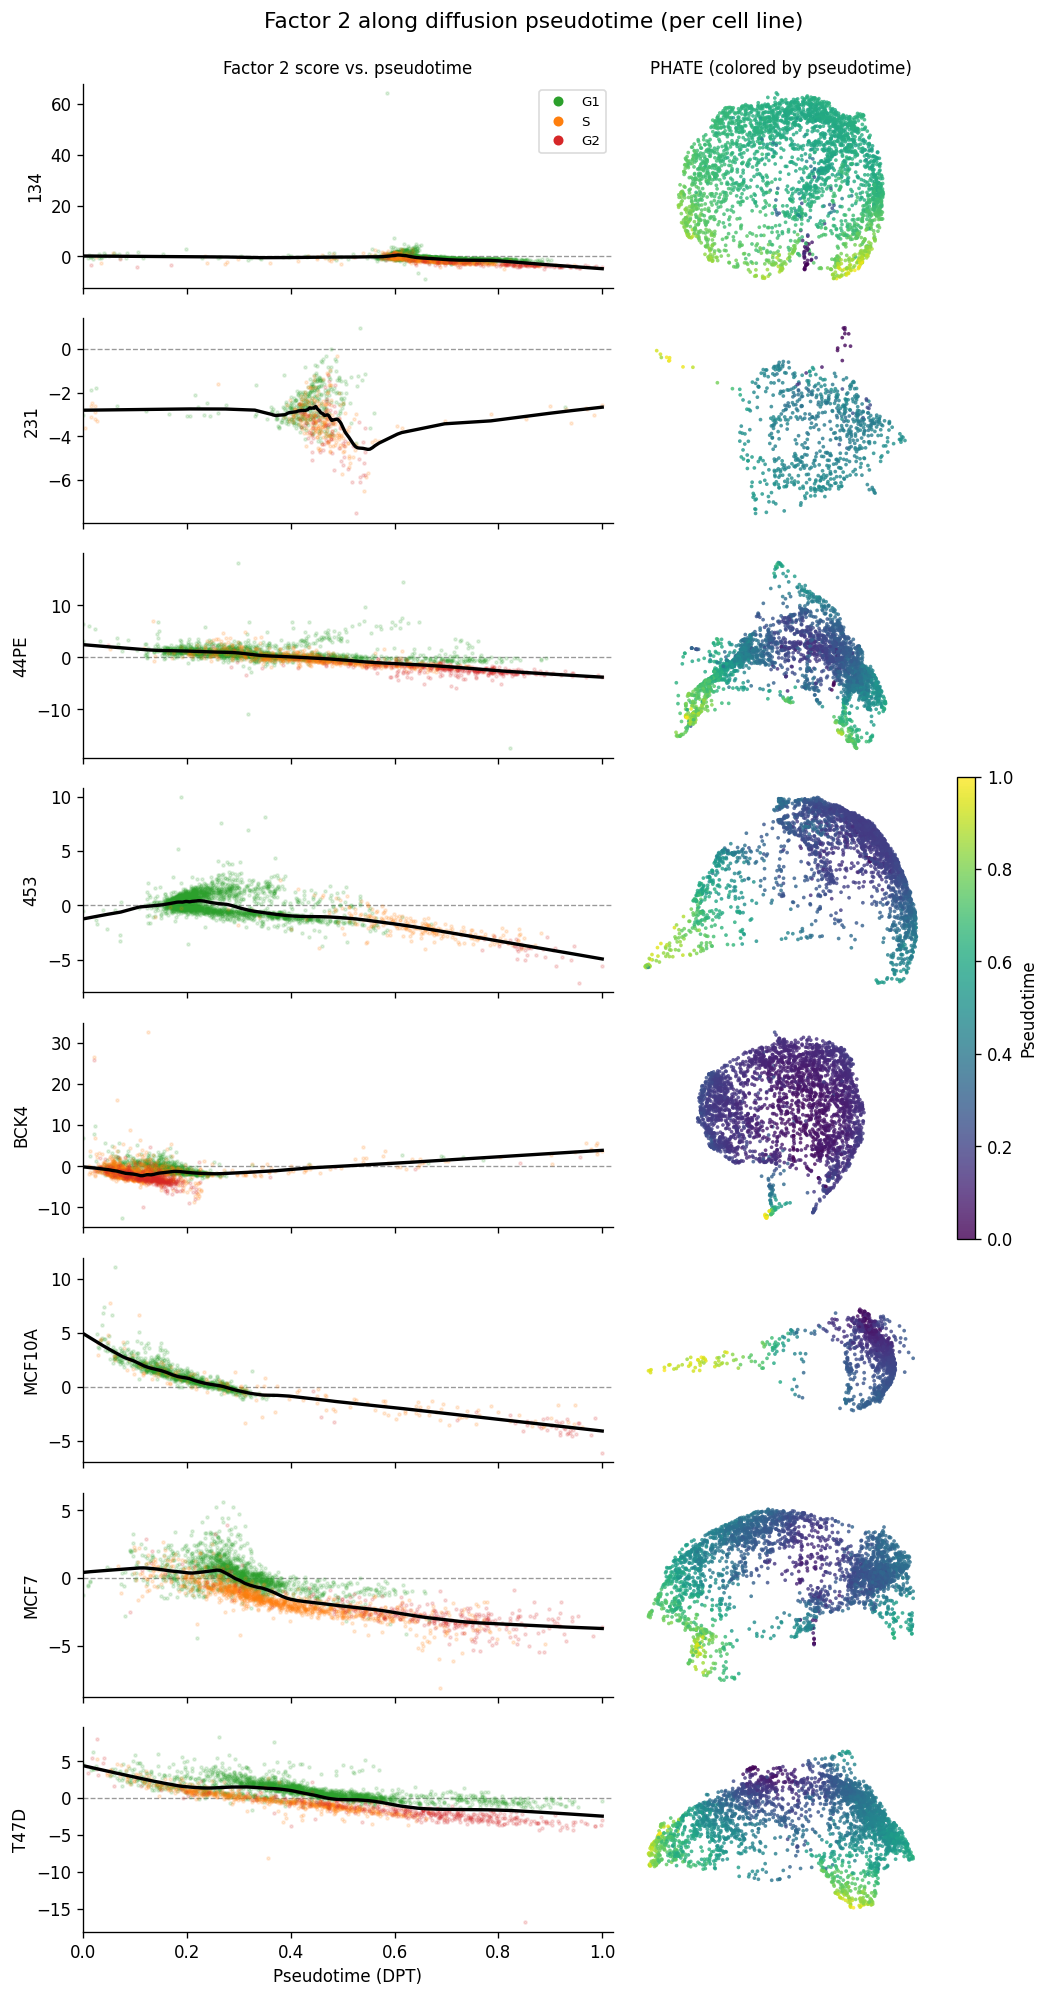

In [24]:
viz.pseudotime_factor_curves(factor=1);

## 8. Save results:

In [25]:
Path("results").mkdir(exist_ok=True)
with open(f"results/cct_drug_{DRUG}.pkl", "wb") as f:
    pickle.dump(cct, f)